To troubleshoot why Pixsplit performs bad on-device, this notebook loads each model, does predictions and creates confusion matrices.

Next steps in find the culprit is simulation.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from sklearn.metrics import accuracy_score
from Plots import plotting
import matplotlib


# Load Vitis into path
os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

In [8]:
model_to_test = 'pixsplit_hgq2'
prediction_dir = 'pixsplit_hgq2/predictions'
plots_export_dir = 'Plots/export/hgq2-cm'

model_configs = [
    {
        "description": "AdaptiveHP acc=0.7084 ebops=864 Distributed Arithmetic",
        "model_revision": "Training_AdaptiveHP",
        "keras_model_path": "pixsplit_hgq2/Training_AdaptiveHP/model_Training_AdaptiveHP_acc=0.7084_ebops=864.keras",
        "hls4ml_strategy": "DA",
        "hls4ml_generate_bitfile": True,
        "hls4ml_revision": "acc=0.7084_ebops=864_VU_DA_bitfile_troubleshooting",
    },
    
    {
        "description": "AdaptiveHP acc=0.7449 ebops=3640 Distributed Arithmetic",
        "model_revision": "Training_AdaptiveHP",
        "keras_model_path": "pixsplit_hgq2/Training_AdaptiveHP/model_Training_AdaptiveHP_acc=0.7449_ebops=3640.keras",
        "hls4ml_strategy": "DA",
        "hls4ml_generate_bitfile": True,
        "hls4ml_revision": "acc=0.7449_ebops=3640_VU_DA_bitfile_troubleshooting",
    },
    
    {
        "description": "AdaptiveHP acc=0.7573 ebops=11698 Distributed Arithmetic",
        "model_revision": "Training_AdaptiveHP",
        "keras_model_path": "pixsplit_hgq2/Training_AdaptiveHP/model_Training_AdaptiveHP_acc=0.7573_ebops=11698.keras",
        "hls4ml_strategy": "DA",
        "hls4ml_generate_bitfile": True,
        "hls4ml_revision": "acc=0.7573_ebops=11698_VU_DA_bitfile_troubleshooting",
    },
]

In [15]:
# Load dataset which is preprocessed in another notebook
# Used for calibration (x) and simulation, which we do not do here

#X_train = np.load("Data/processed_data/X_train.npy")
#X_val = np.load("Data/processed_data/X_val.npy")
x_test = np.load('Data/processed_data/X_test.npy') # used for calibrating
#y_train = np.load("Data/processed_data/y_train.npy")
#y_val = np.load("Data/processed_data/y_val.npy")
y_test = np.load("Data/processed_data/y_test.npy")
classes = ["C1", "C2", "C3"]


x_test = x_test.astype('float32')
x_test.dtype

dtype('float32')

In [10]:
import os

def prepare_directory(model_config):
    output_dir = os.path.join(
        os.path.dirname(os.path.abspath(model_config["keras_model_path"])),
        f"hls4ml_prj_{model_config['hls4ml_revision']}",
    )
    os.makedirs(output_dir, exist_ok=True)
    return output_dir

In [18]:
from keras.models import load_model
import hgq.layers
import hls4ml
from hgq.utils import trace_minmax

def compile_model(keras_model_path, output_dir, hls4ml_strategy):
    model = load_model(keras_model_path)
    
    # Calibrate datalane in HGQ2-model since it has layers with WRAP
    #trace_minmax(model, x_test, verbose=True)
    
    hls_config = hls4ml.utils.config_from_keras_model(model, granularity='name')
    
    strategy = 'Distributed Arithmetic' if hls4ml_strategy == 'DA' else hls4ml_strategy
    hls_config['Model']['Strategy'] = strategy # https://fastmachinelearning.org/hls4ml/api/configuration.html#top-level-configuration

    hls_model = hls4ml.converters.convert_from_keras_model( 
        model,    
        backend     =   'vitisunified',
        hls_config  =   hls_config,
        output_dir  =   output_dir, 
        board       =   'kv260',
        part        =   'xck26-sfvc784-2LV-c',
        in_stream_buf_size = 512,
        clock_period=   '5',
    )
    hls_model.compile()
    return hls_model

In [ ]:
def keras_evaluate_model(keras_model_path):
    model = load_model(keras_model_path)
    y_keras = model.predict(x_test)
    
    from sklearn.metrics import accuracy_score
    #return accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1)) #accuracy_score(y_test, y_hls)
    print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
    return y_keras

In [ ]:
def hls4ml_evaluate_model(hls_model):
    y_hls = hls_model.predict(x_test)
    #y_hls = np.argmax(y_hls,axis=1)
    
    from sklearn.metrics import accuracy_score
    #return accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1)) #accuracy_score(y_test, y_hls)
    #print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
    print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))
    return y_hls

In [33]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def evaluate_cm(prediction, y_true, plotname):
    y_dut = np.argmax(prediction, axis=1)
    cm = confusion_matrix(y_true, y_dut)

    fig, ax = plt.subplots(figsize=(10, 6))
    plotting.plot_confusion_matrix(cm, classes, normalize=True, title=plotname)

    #plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
    plt.tight_layout()
    plt.show()

    fig.savefig(f"{plots_export_dir}/CM_{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")

Processing model 1/3: AdaptiveHP acc=0.7084 ebops=864 Distributed Arithmetic
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
12908/12908 ━━━━━━━━━━━━━━━━━━━━ 3s 265us/step
Keras  Accuracy: 0.7083678341250357
hls4ml Accuracy: 0.7083678341250357


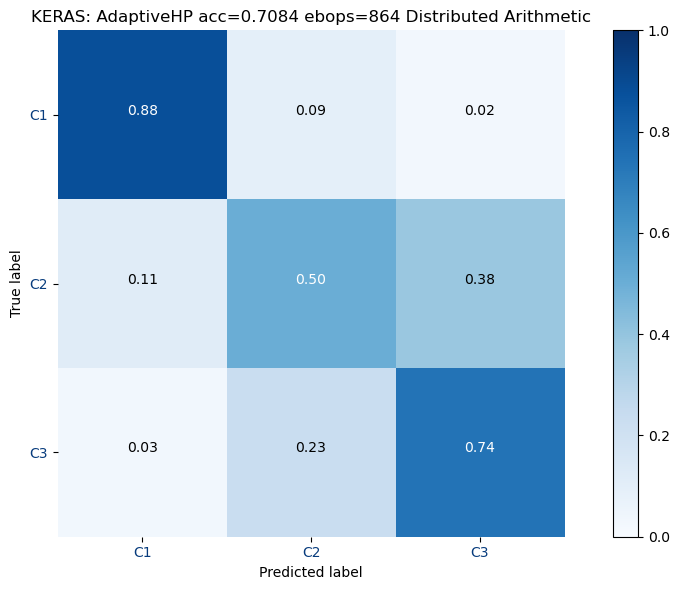

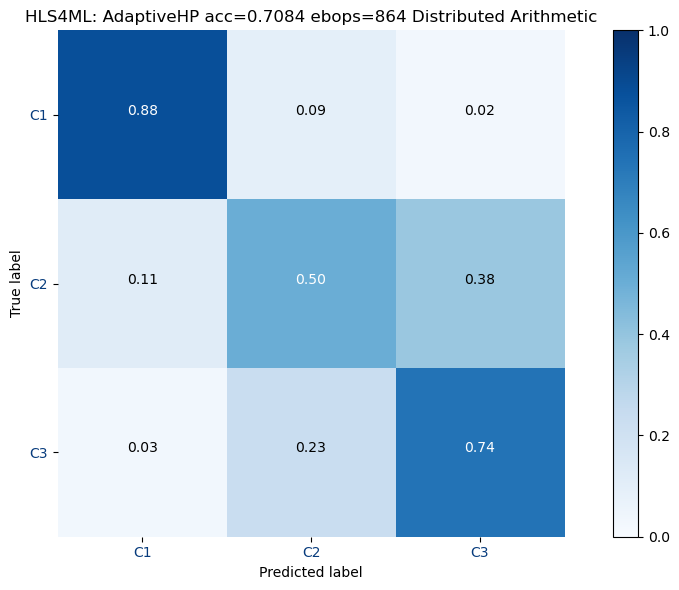

Processing model 2/3: AdaptiveHP acc=0.7449 ebops=3640 Distributed Arithmetic
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
12908/12908 ━━━━━━━━━━━━━━━━━━━━ 3s 257us/step
Keras  Accuracy: 0.7448660400838671
hls4ml Accuracy: 0.7448660400838671


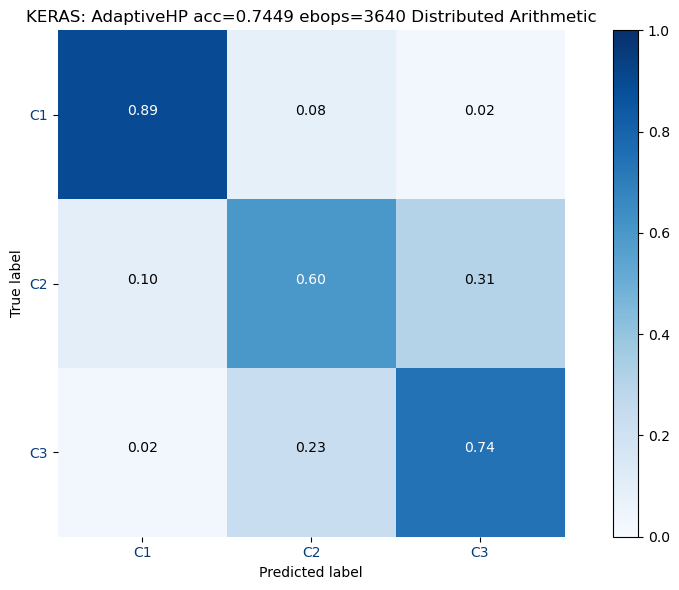

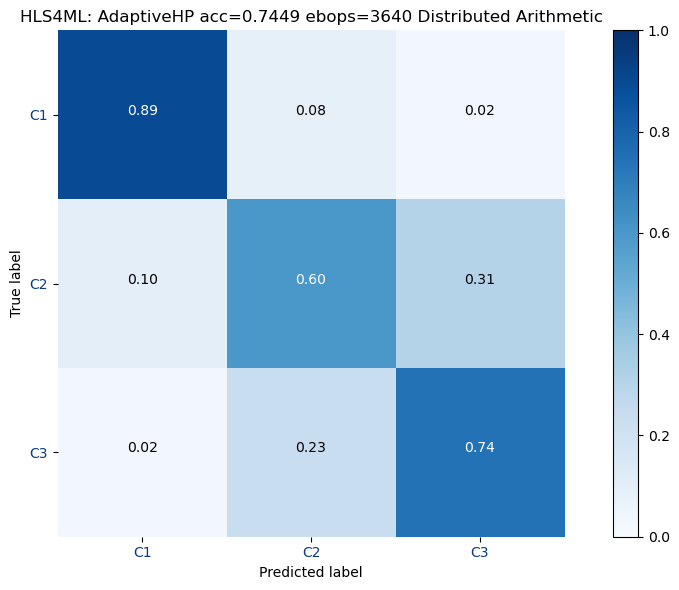

Processing model 3/3: AdaptiveHP acc=0.7573 ebops=11698 Distributed Arithmetic
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
12908/12908 ━━━━━━━━━━━━━━━━━━━━ 3s 266us/step
Keras  Accuracy: 0.7573492739096539
hls4ml Accuracy: 0.7573492739096539


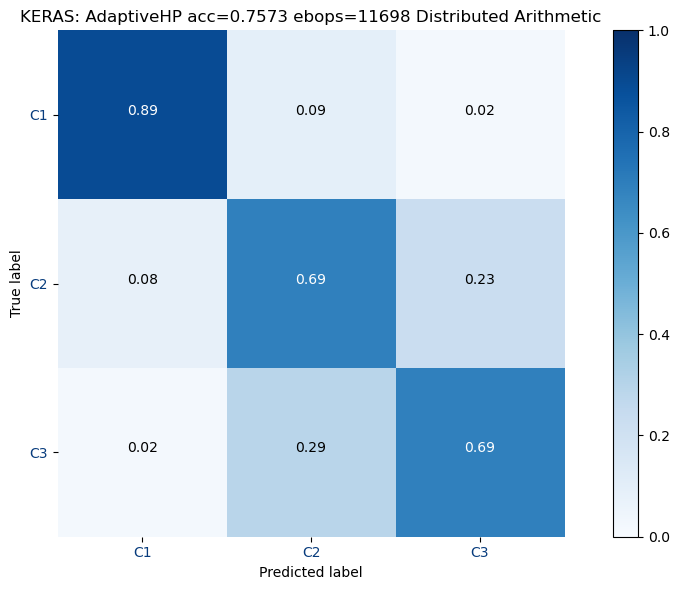

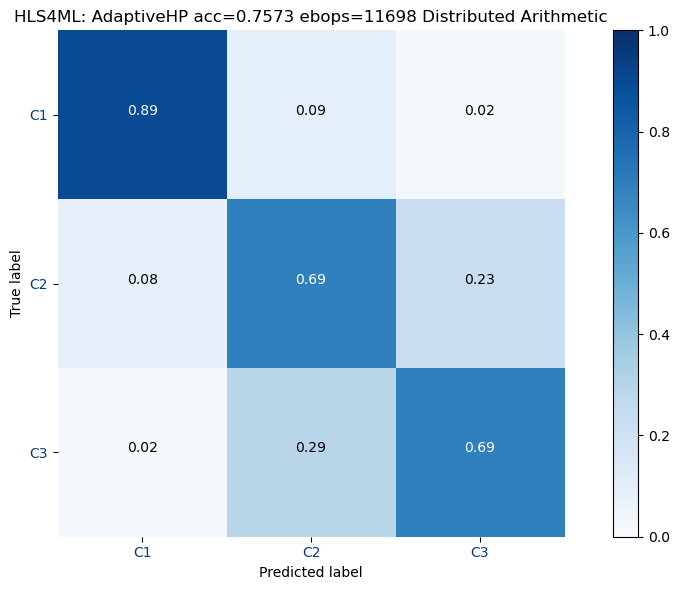

In [34]:
# Hotfix for crashing, see README
os.environ['LD_PRELOAD'] = '/lib/x86_64-linux-gnu/libudev.so.1'

y_true = np.argmax(y_test,axis=1)

# Run through every model
for i, model_config in enumerate(model_configs):
    print(f"Processing model {i+1}/{len(model_configs)}: {model_config['description']}")
    print(f"%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%")
    output_dir = prepare_directory(model_config)
    
    hls_model = compile_model(
        model_config["keras_model_path"],
        output_dir,
        model_config["hls4ml_strategy"],
    )

    y_keras = keras_evaluate_model(model_config["keras_model_path"])
    y_hls = hls4ml_evaluate_model(hls_model)
    np.save(f"{prediction_dir}/y_keras_{model_config['hls4ml_revision']}.npy", y_keras)
    np.save(f"{prediction_dir}/y_hls_{model_config['hls4ml_revision']}.npy", y_hls)

    evaluate_cm(y_keras,y_true,f"KERAS: {model_config['description']}")
    evaluate_cm(y_hls,y_true,f"HLS4ML: {model_config['description']}")




In [24]:
y_true

array([0, 0, 0, ..., 2, 2, 2], shape=(413034,))

In [30]:
np.argmax(np.load("pixsplit_hgq2/predictions/y_keras_acc=0.7084_ebops=864_VU_DA_bitfile_troubleshooting.npy"), axis=1)


array([0, 0, 0, ..., 2, 2, 0], shape=(413034,))